# Solar Power Forecasting — Plant 1: Data Loading

This notebook builds a model to forecast Plant 1's solar power output. This first section loads the raw data and checks its basic shape.

We use two data sources:
1. **Generation data** — inverter-level power output (DC and AC).
2. **Weather data** — ambient temperature, module temperature, and solar irradiation.

Logging (instead of plain `print`) is used throughout so each step's progress is timestamped.


In [1]:
# Section 1: Load data
import os
import logging
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger("solar_forecast")

gen_path = '../data/raw/Plant_1_Generation_Data.csv' if os.path.exists('../data/raw/Plant_1_Generation_Data.csv') else 'Plant_1_Generation_Data.csv'
weather_path = '../data/raw/Plant_1_Weather_Sensor_Data.csv' if os.path.exists('../data/raw/Plant_1_Weather_Sensor_Data.csv') else 'Plant_1_Weather_Sensor_Data.csv'

logger.info("Loading Plant 1 generation and weather data...")
plant1_gen_df = pd.read_csv(gen_path)
plant1_weather_df = pd.read_csv(weather_path)

logger.info(f"Generation data: {plant1_gen_df.shape[0]:,} rows x {plant1_gen_df.shape[1]} columns")
logger.info(f"Weather data: {plant1_weather_df.shape[0]:,} rows x {plant1_weather_df.shape[1]} columns")

print(plant1_gen_df.head(5).to_string(index=False))


2026-07-05 17:22:27 [INFO] Loading Plant 1 generation and weather data...


2026-07-05 17:22:27 [INFO] Generation data: 68,778 rows x 7 columns


2026-07-05 17:22:27 [INFO] Weather data: 3,182 rows x 6 columns


       DATE_TIME  PLANT_ID      SOURCE_KEY  DC_POWER  AC_POWER  DAILY_YIELD  TOTAL_YIELD
15-05-2020 00:00   4135001 1BY6WEcLGh8j5v7       0.0       0.0          0.0    6259559.0
15-05-2020 00:00   4135001 1IF53ai7Xc0U56Y       0.0       0.0          0.0    6183645.0
15-05-2020 00:00   4135001 3PZuoBAID5Wc2HD       0.0       0.0          0.0    6987759.0
15-05-2020 00:00   4135001 7JYdWkrLSPkdwr4       0.0       0.0          0.0    7602960.0
15-05-2020 00:00   4135001 McdE0feGgRqW7Ca       0.0       0.0          0.0    7158964.0


## 2. Inspect schema and parse timestamps

Check column types and missing values, then convert `DATE_TIME` to an actual datetime (each source file uses a different string format), and confirm the date range covers the expected 34 days.


In [2]:
# Section 2: Schema check and datetime parsing
print("\nFirst 5 rows of weather data:")
print(plant1_weather_df.head(5).to_string(index=False))

inverter_count = plant1_gen_df['SOURCE_KEY'].nunique()
logger.info(f"Found {inverter_count} unique inverters (SOURCE_KEY) in Plant 1.")

print("\n--- Generation data info ---")
plant1_gen_df.info()

print("\n--- Weather data info ---")
plant1_weather_df.info()

# Convert timestamps (each source file uses a different string format)
plant1_gen_df['DATE_TIME'] = pd.to_datetime(plant1_gen_df['DATE_TIME'], format='%d-%m-%Y %H:%M')
plant1_weather_df['DATE_TIME'] = pd.to_datetime(plant1_weather_df['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

start_boundary = plant1_gen_df['DATE_TIME'].min()
end_boundary = plant1_gen_df['DATE_TIME'].max()
logger.info(f"Data covers {start_boundary} to {end_boundary}.")


2026-07-05 17:22:27 [INFO] Found 22 unique inverters (SOURCE_KEY) in Plant 1.


2026-07-05 17:22:27 [INFO] Data covers 2020-05-15 00:00:00 to 2020-06-17 23:45:00.



First 5 rows of weather data:
          DATE_TIME  PLANT_ID      SOURCE_KEY  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION
2020-05-15 00:00:00   4135001 HmiyD2TTLFNqkNe            25.184316           22.857507          0.0
2020-05-15 00:15:00   4135001 HmiyD2TTLFNqkNe            25.084589           22.761668          0.0
2020-05-15 00:30:00   4135001 HmiyD2TTLFNqkNe            24.935753           22.592306          0.0
2020-05-15 00:45:00   4135001 HmiyD2TTLFNqkNe            24.846130           22.360852          0.0
2020-05-15 01:00:00   4135001 HmiyD2TTLFNqkNe            24.621525           22.165423          0.0

--- Generation data info ---
<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  str    
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  str    
 3   DC_POWER     68778 non-null

## 3. DC vs AC power on a single day

To sanity-check the data, plot one day (`2020-05-15`) of DC and AC power, averaged across all inverters. This confirms the panel-side (DC) and grid-side (AC) power track the expected daily solar curve.


2026-07-05 17:22:27 [INFO] Plotting DC vs AC power for 2020-05-15


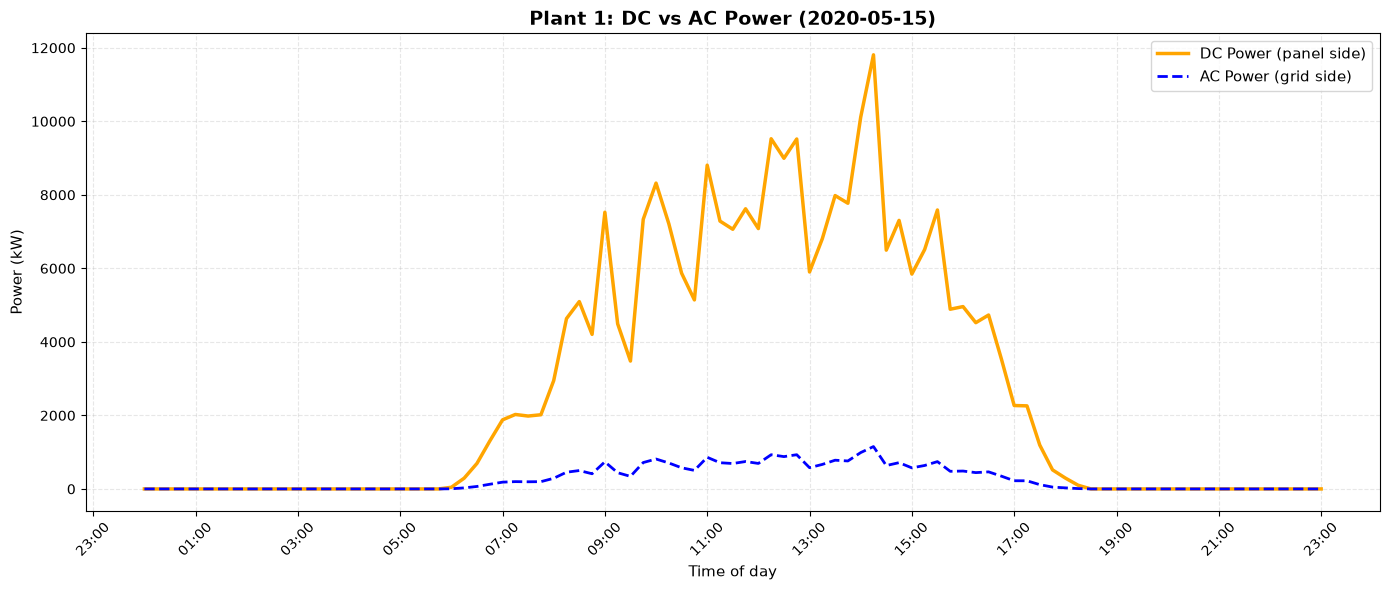

In [3]:
# Section 3: DC vs AC power profile for one day
target_date = '2020-05-15'
logger.info(f"Plotting DC vs AC power for {target_date}")

day_df = plant1_gen_df[plant1_gen_df['DATE_TIME'].dt.date == pd.to_datetime(target_date).date()].copy()
hourly_avg = day_df.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER']].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(hourly_avg['DATE_TIME'], hourly_avg['DC_POWER'], label='DC Power (panel side)', color='orange', lw=2.5)
plt.plot(hourly_avg['DATE_TIME'], hourly_avg['AC_POWER'], label='AC Power (grid side)', color='blue', lw=2.0, linestyle='--')

# Space ticks every 2 hours to avoid overlapping labels
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.title(f"Plant 1: DC vs AC Power ({target_date})", fontsize=14, fontweight='bold')
plt.xlabel("Time of day", fontsize=11)
plt.ylabel("Power (kW)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Daily energy yield

Look at the maximum `DAILY_YIELD` value reached each day (34 days total) — this is the day's total energy output.


2026-07-05 17:22:27 [INFO] Computing max DAILY_YIELD per day.


2026-07-05 17:22:27 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:27 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


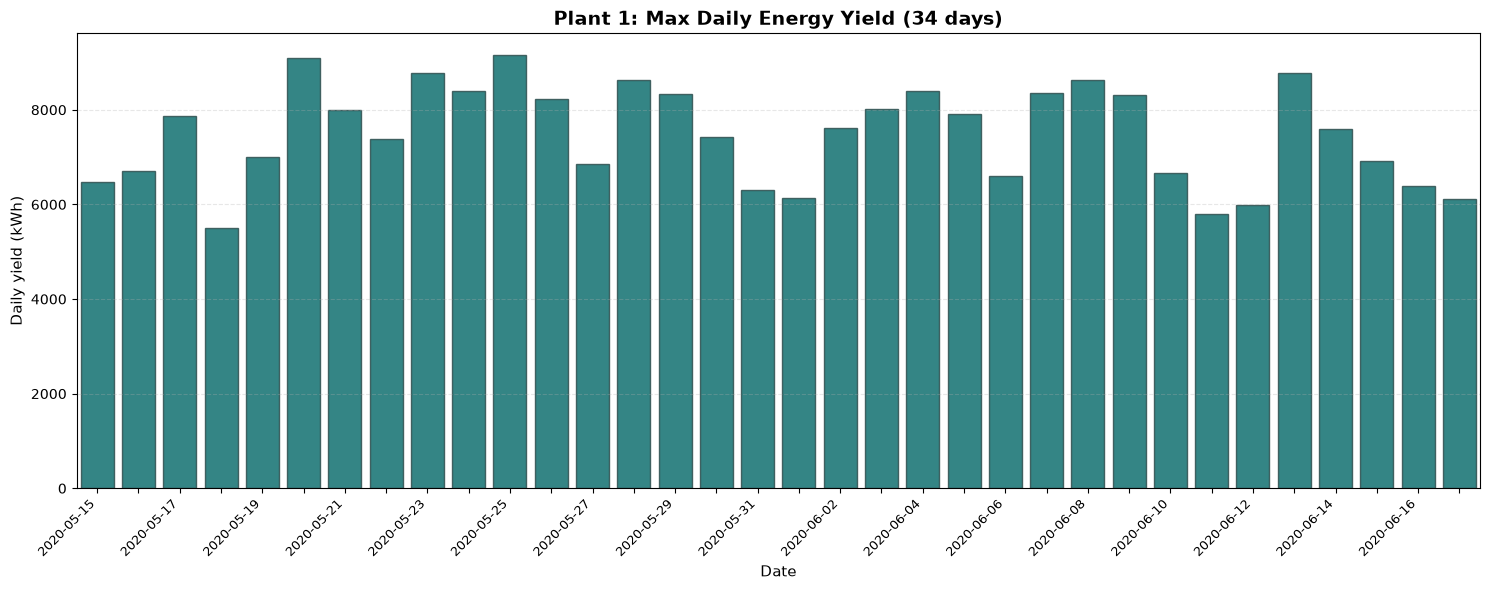

In [4]:
# Section 4: Daily energy yield
logger.info("Computing max DAILY_YIELD per day.")

plant1_gen_df['DATE_STR'] = plant1_gen_df['DATE_TIME'].dt.strftime('%Y-%m-%d')
daily_yield_max = plant1_gen_df.groupby('DATE_STR')['DAILY_YIELD'].max().reset_index()

plt.figure(figsize=(15, 6))
ax = sns.barplot(data=daily_yield_max, x='DATE_STR', y='DAILY_YIELD', color='teal', edgecolor='darkslategray', alpha=0.85)

# Show every other date label to avoid overlapping text
x_indices = np.arange(len(daily_yield_max))
ax.set_xticks(x_indices)
tick_labels = [label if i % 2 == 0 else '' for i, label in enumerate(daily_yield_max['DATE_STR'])]
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=9)

plt.title("Plant 1: Max Daily Energy Yield (34 days)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Daily yield (kWh)", fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Total cumulative yield over time

Sum `TOTAL_YIELD` across all inverters at each timestamp to see the plant's lifetime cumulative output trend.


2026-07-05 17:22:27 [INFO] Summing TOTAL_YIELD across all inverters per timestamp.


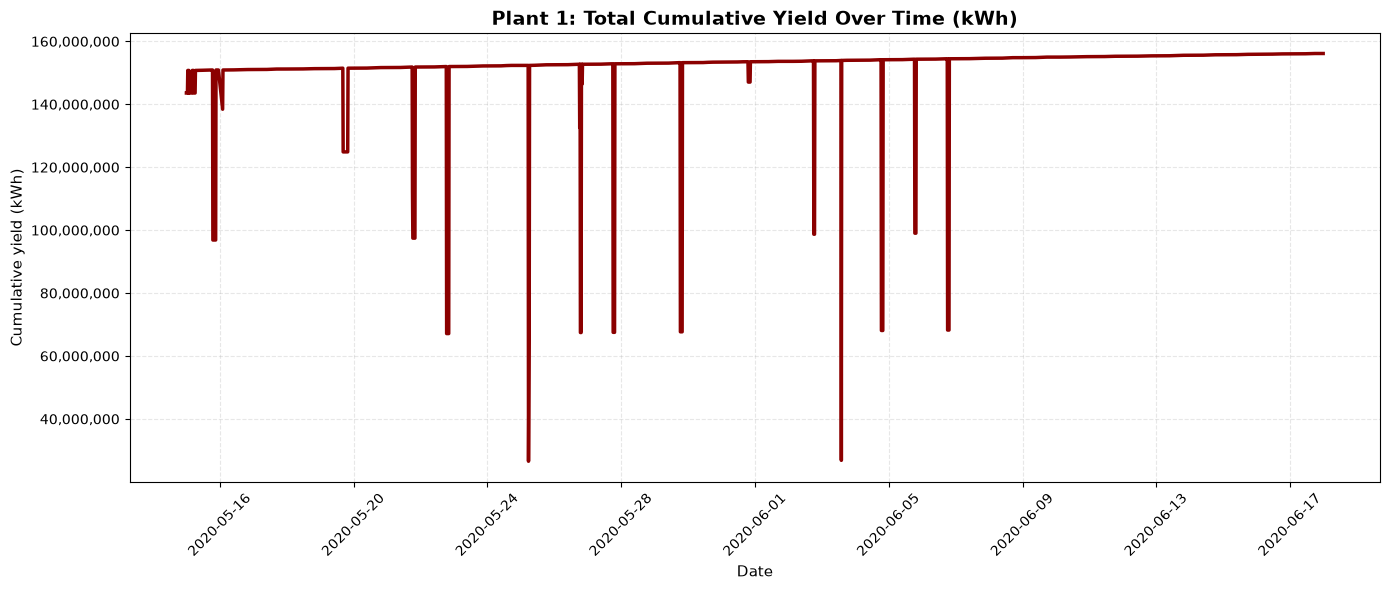

In [5]:
# Section 5: Total cumulative yield over time
logger.info("Summing TOTAL_YIELD across all inverters per timestamp.")

total_yield_trend = plant1_gen_df.groupby('DATE_TIME')['TOTAL_YIELD'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(total_yield_trend['DATE_TIME'], total_yield_trend['TOTAL_YIELD'], color='darkred', lw=2.5)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
# Avoid scientific notation (e.g. 1e7) on the y-axis
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.title("Plant 1: Total Cumulative Yield Over Time (kWh)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Cumulative yield (kWh)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Weather trends

Plot the 34-day ambient vs module temperature trend, and the irradiation curve for one day (`2020-05-15`). Module temperature runs hotter than ambient air due to panel heat absorption, and irradiation should track the solar day.


2026-07-05 17:22:27 [INFO] Plotting temperature and irradiation trends.


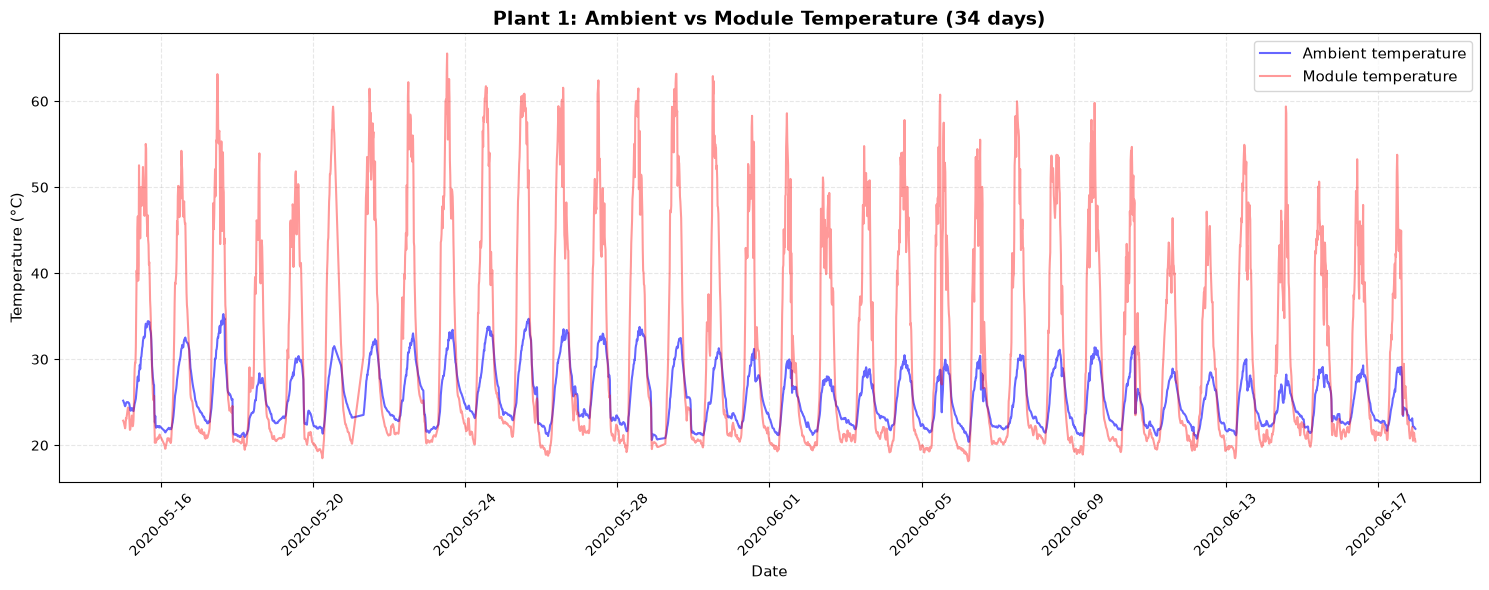

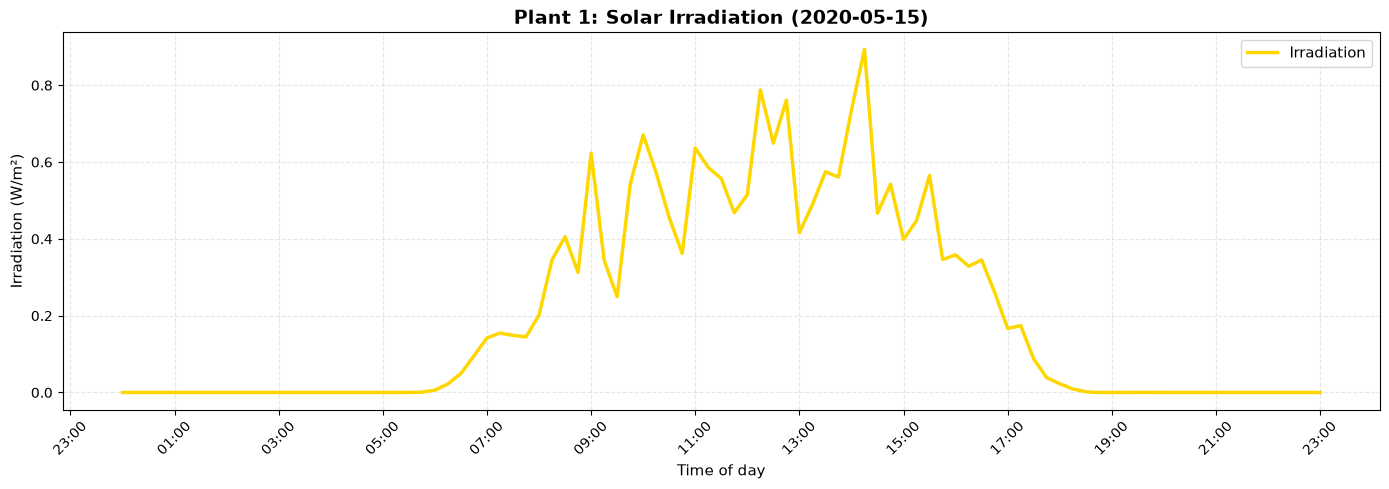

In [6]:
# Section 6: Weather trends
logger.info("Plotting temperature and irradiation trends.")

# Chart 1: 34-day ambient vs module temperature
plt.figure(figsize=(15, 6))
plt.plot(plant1_weather_df['DATE_TIME'], plant1_weather_df['AMBIENT_TEMPERATURE'], label='Ambient temperature', color='blue', alpha=0.6, lw=1.5)
plt.plot(plant1_weather_df['DATE_TIME'], plant1_weather_df['MODULE_TEMPERATURE'], label='Module temperature', color='red', alpha=0.4, lw=1.5)

ax1 = plt.gca()
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=4))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Plant 1: Ambient vs Module Temperature (34 days)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Temperature (°C)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 2: irradiation curve for a single day
target_date_weather = '2020-05-15'
day_weather_df = plant1_weather_df[plant1_weather_df['DATE_TIME'].dt.date == pd.to_datetime(target_date_weather).date()].copy()

plt.figure(figsize=(14, 5))
plt.plot(day_weather_df['DATE_TIME'], day_weather_df['IRRADIATION'], color='gold', lw=2.5, label='Irradiation')

ax2 = plt.gca()
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.title(f"Plant 1: Solar Irradiation ({target_date_weather})", fontsize=14, fontweight='bold')
plt.xlabel("Time of day", fontsize=11)
plt.ylabel("Irradiation (W/m²)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Daily summary statistics

Summarize `DAILY_YIELD` and `DC_POWER` per day (max, min, mean, median, count) to spot potential sensor dropouts or clipping before building features.


In [7]:
# Section 7: Daily summary statistics
logger.info("Computing daily summary stats for yield and DC power.")

if 'DATE_STR' not in plant1_gen_df.columns:
    plant1_gen_df['DATE_STR'] = plant1_gen_df['DATE_TIME'].dt.strftime('%Y-%m-%d')

daily_summary = plant1_gen_df.groupby('DATE_STR').agg({
    'DAILY_YIELD': ['max', 'min', 'mean', 'median', 'count'],
    'DC_POWER': ['max', 'min', 'mean', 'median']
}).reset_index()

daily_summary.columns = [
    'date',
    'yield_max', 'yield_min', 'yield_mean', 'yield_median', 'row_count',
    'dc_max', 'dc_min', 'dc_mean', 'dc_median'
]
daily_summary = daily_summary.sort_values('date').reset_index(drop=True)

pd.set_option('display.max_rows', 50)
print(daily_summary.to_string(index=False, formatters={
    'yield_max': '{:,.1f}'.format, 'yield_min': '{:,.1f}'.format, 'yield_mean': '{:,.1f}'.format, 'yield_median': '{:,.1f}'.format,
    'dc_max': '{:,.2f}'.format, 'dc_min': '{:,.2f}'.format, 'dc_mean': '{:,.2f}'.format, 'dc_median': '{:,.2f}'.format,
    'row_count': '{:,}'.format
}))


2026-07-05 17:22:27 [INFO] Computing daily summary stats for yield and DC power.


      date yield_max yield_min yield_mean yield_median row_count    dc_max dc_min  dc_mean dc_median
2020-05-15   6,471.0       0.0    2,586.3      1,646.8     1,954 12,319.14   0.00 2,879.86    690.81
2020-05-16   6,714.0       0.0    3,464.3      3,866.4     1,934 11,986.57   0.00 3,002.14  1,051.88
2020-05-17   7,867.0       0.0    3,695.1      3,819.8     2,112 13,217.43   0.00 3,200.57    128.00
2020-05-18   5,506.0       0.0    2,429.1      1,601.5     2,112 13,382.75   0.00 2,278.67    275.57
2020-05-19   7,007.0       0.0    2,963.0      1,699.8     1,990 11,911.50   0.00 2,732.64      0.00
2020-05-20   9,102.0       0.0    3,356.8      1,393.1     1,672 13,241.14   0.00 3,215.06      0.00
2020-05-21   7,993.0       0.0    4,844.5      5,919.0     1,368 14,038.29   0.00 4,956.92  4,842.26
2020-05-22   7,378.0       0.0    2,739.6      1,139.9     2,028 14,300.29   0.00 3,166.02    531.44
2020-05-23   8,783.0       0.0    4,325.3      4,603.2     1,958 13,848.00   0.00 3,896.94 

## 8. DC power per day (small multiples)

Plot each of the 34 days as its own scatter of DC power over time, so equipment dropouts on a specific day are easy to spot visually.


2026-07-05 17:22:27 [INFO] Plotting DC power per day across all 34 days.


2026-07-05 17:22:28 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:28 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:28 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:28 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

2026-07-05 17:22:28 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:28 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:28 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:28 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:28 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


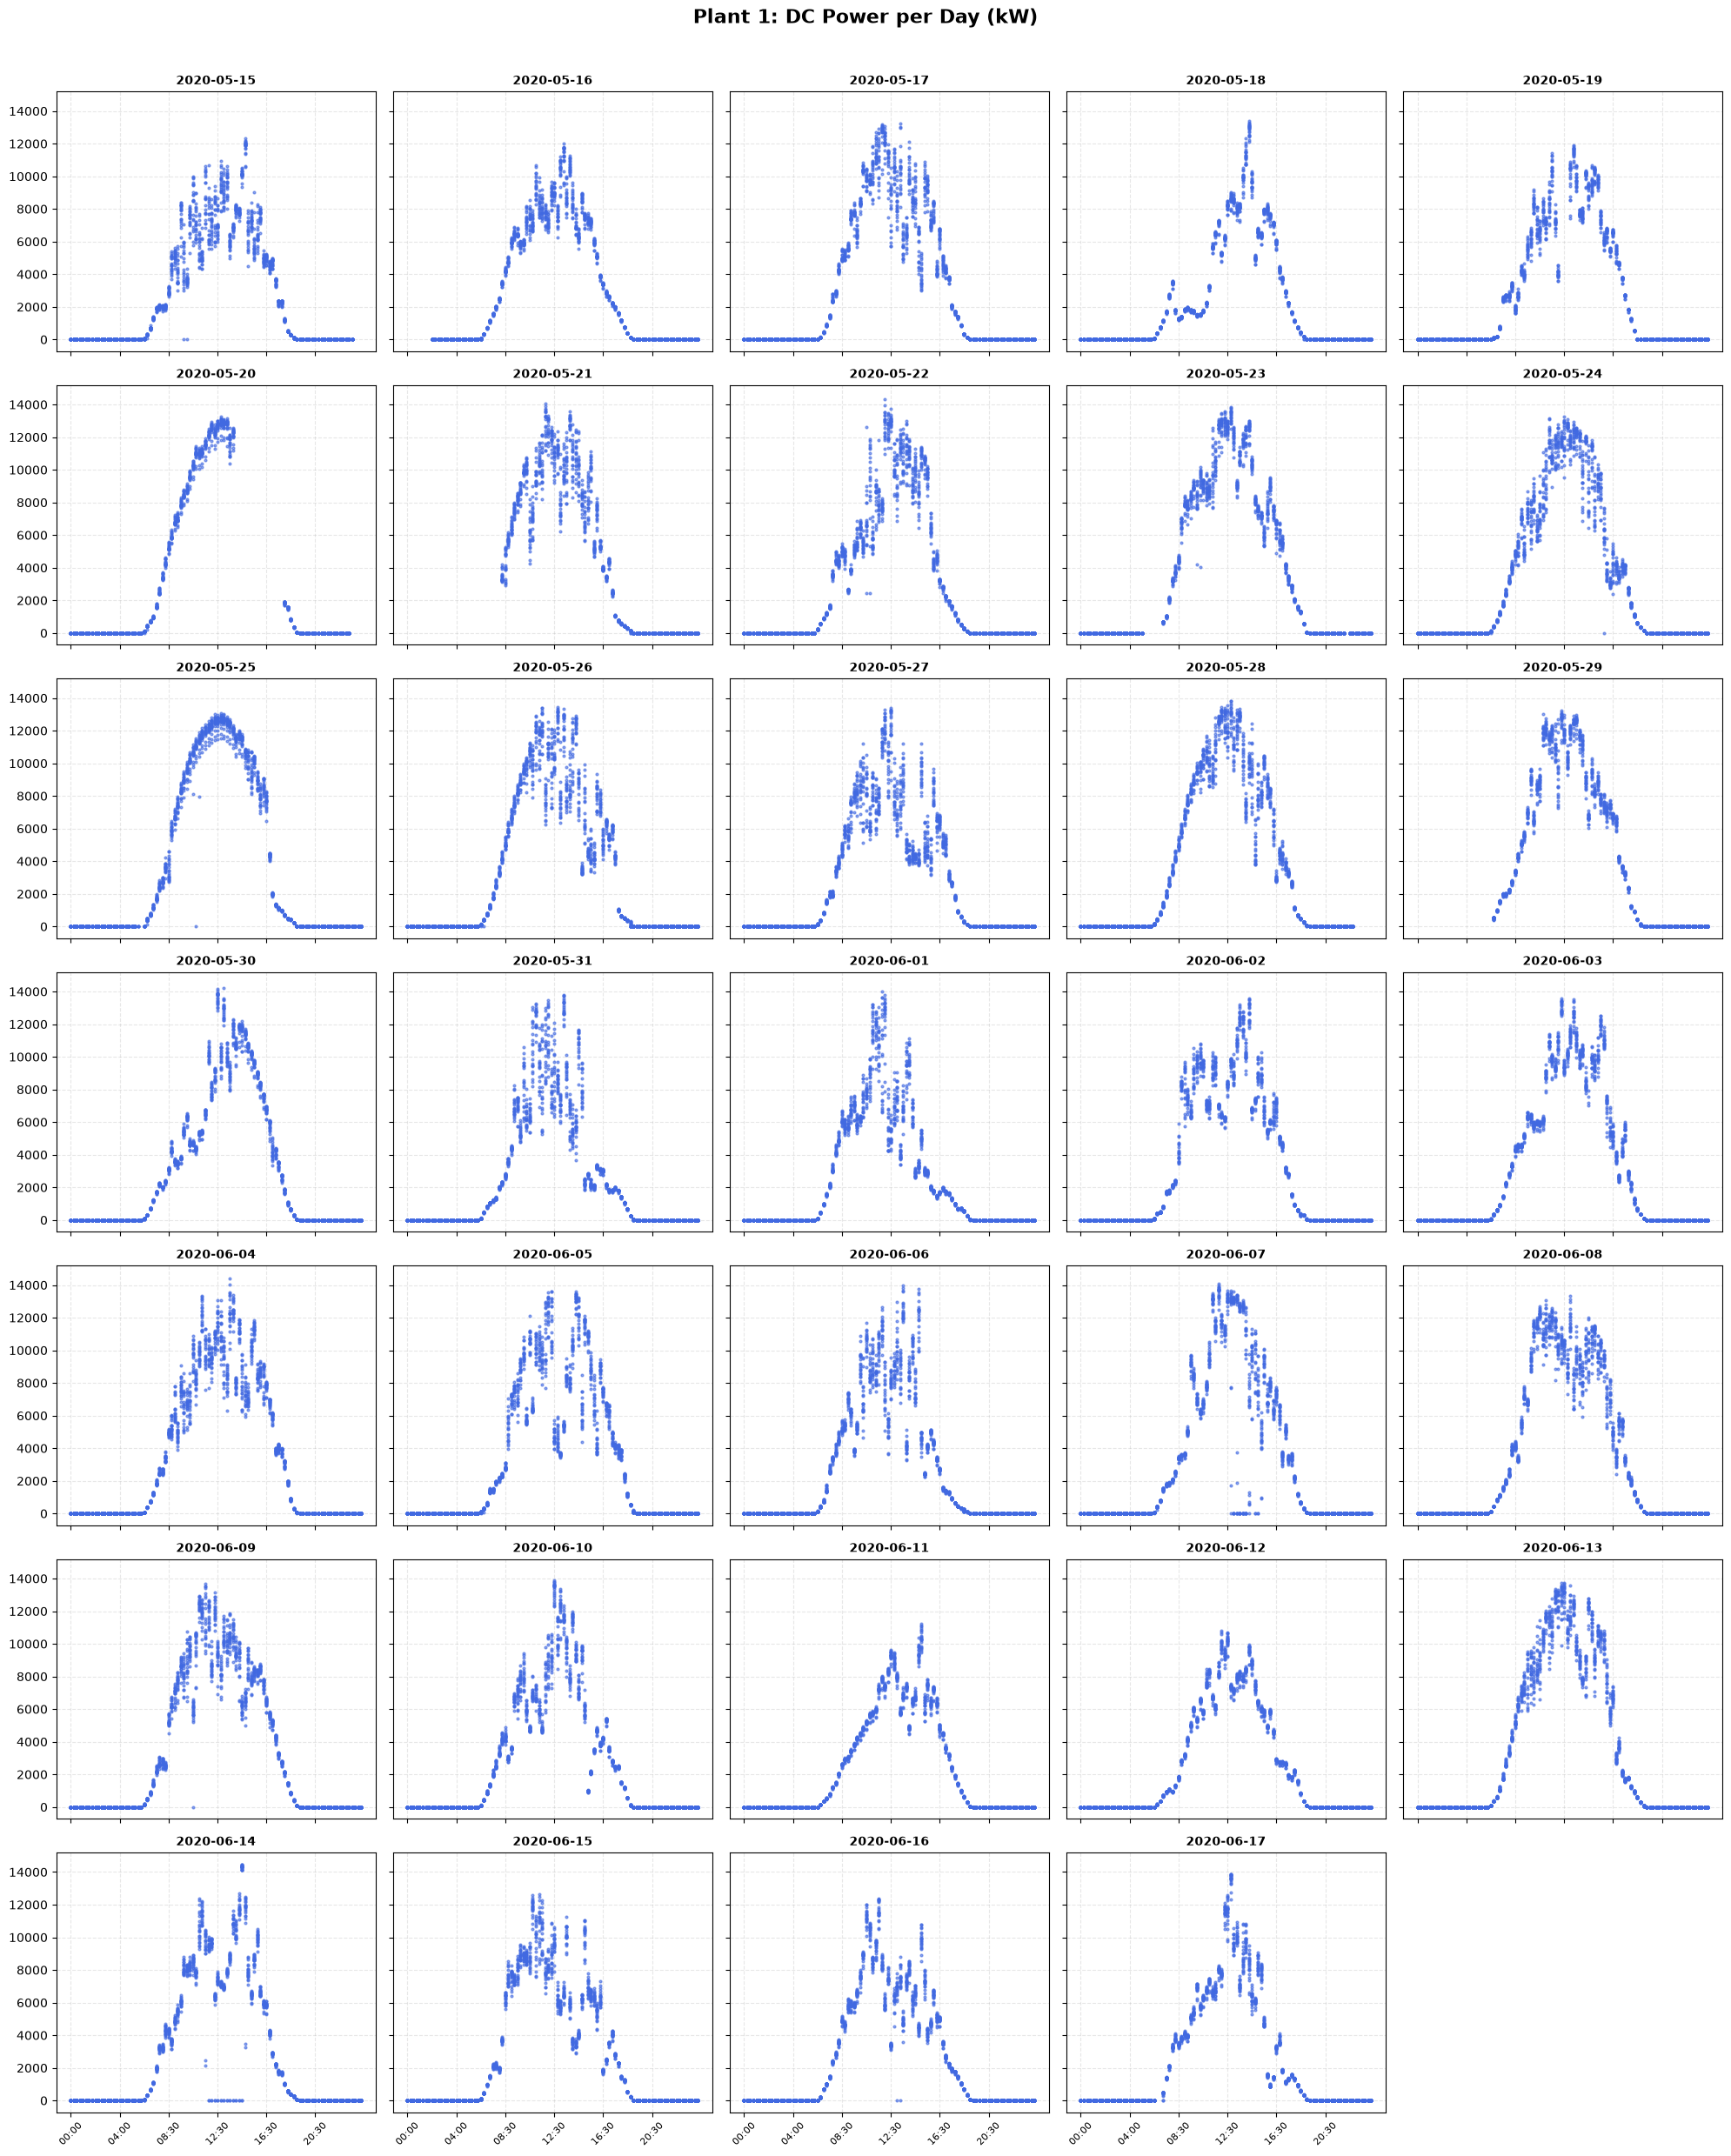

In [8]:
# Section 8: DC power per day, small multiples
logger.info("Plotting DC power per day across all 34 days.")

p1_gen_clean = plant1_gen_df.copy()
p1_gen_clean['DATE_TIME'] = pd.to_datetime(p1_gen_clean['DATE_TIME'])
p1_gen_clean['DATE_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%Y-%m-%d')
p1_gen_clean['TIME_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%H:%M')

unique_dates = sorted(p1_gen_clean['DATE_STR'].unique())
total_plots = len(unique_dates)

cols = 5
rows = math.ceil(total_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3.5), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, current_date in enumerate(unique_dates):
    day_df = p1_gen_clean[p1_gen_clean['DATE_STR'] == current_date].sort_values('DATE_TIME')
    ax = axes_flat[i]

    ax.plot(day_df['TIME_STR'], day_df['DC_POWER'], marker='.', linestyle='None', color='royalblue', alpha=0.6, markersize=4)
    ax.set_title(current_date, fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)

    # Show a tick every 4 hours (16 x 15-minute intervals)
    target_indices = np.arange(0, len(day_df['TIME_STR'].unique()), 16)
    ax.set_xticks(target_indices)
    ax.set_xticklabels(sorted(day_df['TIME_STR'].unique())[::16], rotation=45, fontsize=8)

for j in range(total_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

fig.suptitle("Plant 1: DC Power per Day (kW)", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 9. Daily yield per day (small multiples)

Same small-multiples view, but for the plant-wide summed `DAILY_YIELD` instead of DC power — useful for spotting counting/accumulation anomalies.


2026-07-05 17:22:28 [INFO] Plotting total daily yield per day across all 34 days.


2026-07-05 17:22:29 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:29 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:29 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:29 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

2026-07-05 17:22:29 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:29 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:29 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:29 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:29 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


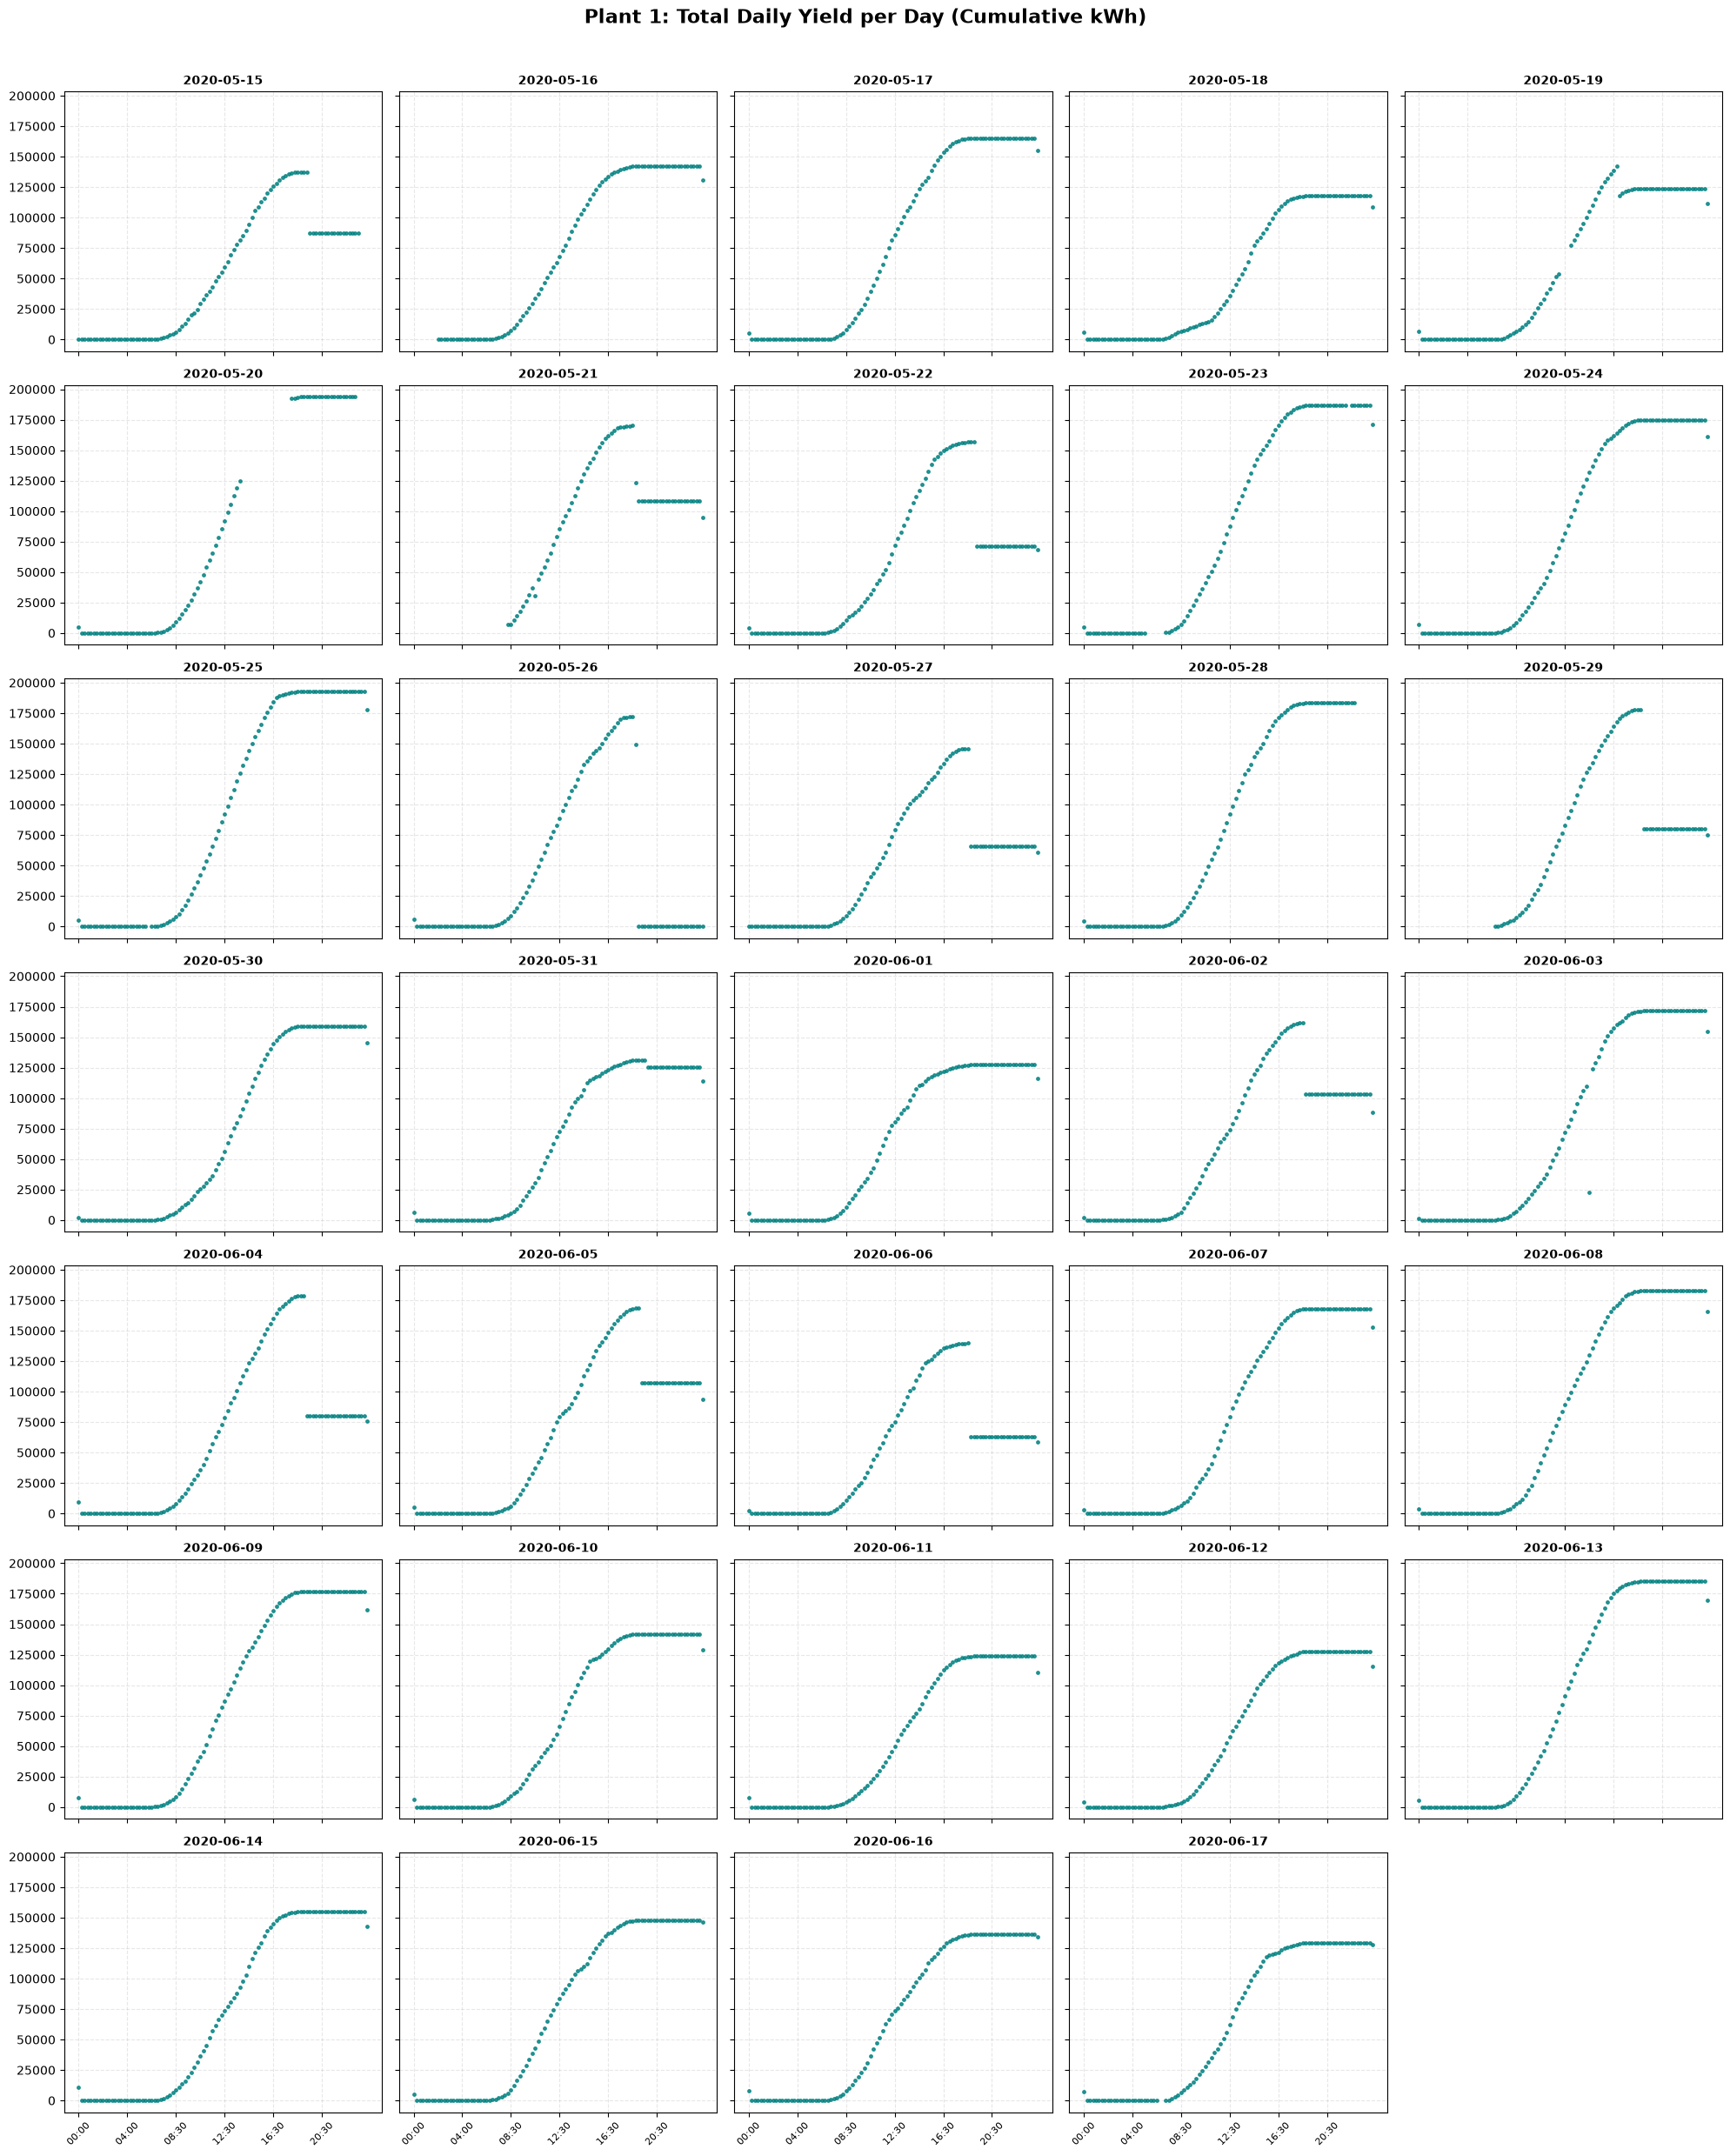

In [9]:
# Section 9: Daily yield per day, small multiples
logger.info("Plotting total daily yield per day across all 34 days.")

p1_gen_clean = plant1_gen_df.copy()
p1_gen_clean['DATE_TIME'] = pd.to_datetime(p1_gen_clean['DATE_TIME'])
p1_gen_clean['DATE_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%Y-%m-%d')
p1_gen_clean['TIME_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%H:%M')

plant_total_yield = p1_gen_clean.groupby(['DATE_STR', 'TIME_STR', 'DATE_TIME'])['DAILY_YIELD'].sum().reset_index()

unique_dates = sorted(plant_total_yield['DATE_STR'].unique())
total_plots = len(unique_dates)

cols = 5
rows = math.ceil(total_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3.5), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, current_date in enumerate(unique_dates):
    day_df = plant_total_yield[plant_total_yield['DATE_STR'] == current_date].sort_values('DATE_TIME')
    ax = axes_flat[i]

    ax.plot(day_df['TIME_STR'], day_df['DAILY_YIELD'], marker='.', linestyle='None', color='teal', alpha=0.8, markersize=5)
    ax.set_title(current_date, fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)

    target_indices = np.arange(0, len(day_df['TIME_STR'].unique()), 16)
    ax.set_xticks(target_indices)
    ax.set_xticklabels(sorted(day_df['TIME_STR'].unique())[::16], rotation=45, fontsize=8)

for j in range(total_plots, len(axes_flat)):
    fig.delaxes(axes_flat[j])

fig.suptitle("Plant 1: Total Daily Yield per Day (Cumulative kWh)", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 10. Missing-data checks

Each day should have 2,112 readings (22 inverters × 96 fifteen-minute intervals). Flag any day below that count as a possible outage, and flag days with complete data but unusually low yield as possible shutdowns.


In [10]:
# Section 10: Missing-data checks
logger.info("Checking for days with missing readings or unusually low yield.")

p1_gen_clean = plant1_gen_df.copy()
if 'DATE_STR' not in p1_gen_clean.columns:
    p1_gen_clean['DATE_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%Y-%m-%d')

cleaning_check = p1_gen_clean.groupby('DATE_STR').agg({
    'DAILY_YIELD': 'max',
    'DC_POWER': 'max',
    'DATE_TIME': 'count'
}).reset_index()
cleaning_check.columns = ['date', 'yield_max', 'dc_max', 'row_count']
cleaning_check = cleaning_check.sort_values('date').reset_index(drop=True)

# Expected full-day row count: 22 inverters x 96 intervals = 2,112
flagged_outages = cleaning_check[cleaning_check['row_count'] < 2112]
# Among days with complete data, flag unusually low yield (possible shutdown)
flagged_low_perf = cleaning_check[(cleaning_check['yield_max'] < 4000) & (cleaning_check['row_count'] == 2112)]

print("\nDays with missing readings:")
if not flagged_outages.empty:
    logger.warning(f"{len(flagged_outages)} day(s) have fewer than 2,112 readings.")
    print(flagged_outages.to_string(index=False, formatters={
        'yield_max': '{:,.1f}'.format, 'dc_max': '{:,.2f}'.format, 'row_count': '{:,}'.format
    }))
else:
    print("None — all days have the expected 2,112 readings.")

print("\nDays with complete data but low yield:")
if not flagged_low_perf.empty:
    logger.warning(f"{len(flagged_low_perf)} day(s) have unusually low yield despite complete data.")
    print(flagged_low_perf.to_string(index=False, formatters={
        'yield_max': '{:,.1f}'.format, 'dc_max': '{:,.2f}'.format, 'row_count': '{:,}'.format
    }))
else:
    print("None.")


2026-07-05 17:22:29 [INFO] Checking for days with missing readings or unusually low yield.


2026-07-05 17:22:29 [WARNING] 19 day(s) have fewer than 2,112 readings.



Days with missing readings:
      date yield_max    dc_max row_count
2020-05-15   6,471.0 12,319.14     1,954
2020-05-16   6,714.0 11,986.57     1,934
2020-05-19   7,007.0 11,911.50     1,990
2020-05-20   9,102.0 13,241.14     1,672
2020-05-21   7,993.0 14,038.29     1,368
2020-05-22   7,378.0 14,300.29     2,028
2020-05-23   8,783.0 13,848.00     1,958
2020-05-25   9,163.0 13,060.71     2,060
2020-05-26   8,222.0 13,434.43     2,072
2020-05-27   6,857.0 13,402.88     2,052
2020-05-28   8,636.0 13,810.57     1,980
2020-05-29   8,343.0 13,236.57     1,490
2020-05-31   6,300.0 13,774.14     2,106
2020-06-02   7,607.0 13,579.57     2,088
2020-06-03   8,010.0 13,579.43     2,094
2020-06-04   8,391.7 14,413.43     2,052
2020-06-05   7,920.0 13,598.57     2,080
2020-06-06   6,603.0 13,958.14     2,052
2020-06-17   6,110.0 13,869.57     2,068

Days with complete data but low yield:
None.


## 11. Finding faulty inverters at peak hours

During peak sun (11:00–15:00), DC power should never be 0 kW. Count how often each inverter reads exactly 0 during this window on each day, and flag inverters with more than 4 such readings (over 1 hour) as likely hardware faults rather than passing clouds.


In [11]:
# Section 11: Finding faulty inverters at peak hours
logger.info("Screening for inverters with sustained zero output during peak hours (11:00-15:00).")

p1_gen_clean = plant1_gen_df.copy()
p1_gen_clean['DATE_TIME'] = pd.to_datetime(p1_gen_clean['DATE_TIME'])
p1_gen_clean['DATE_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%Y-%m-%d')
p1_gen_clean['TIME_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%H:%M')

peak_df = p1_gen_clean[(p1_gen_clean['TIME_STR'] >= '11:00') & (p1_gen_clean['TIME_STR'] <= '15:00')].copy()

culprit_hunting = peak_df.groupby(['DATE_STR', 'SOURCE_KEY']).agg({
    'DC_POWER': lambda x: (x == 0.0).sum()
}).reset_index()
culprit_hunting.columns = ['date', 'inverter_id', 'zero_count_noon']

# More than 4 zero readings (over 1 continuous hour) suggests a hardware fault, not a passing cloud
detected_culprits = culprit_hunting[culprit_hunting['zero_count_noon'] > 4].copy()
detected_culprits = detected_culprits.sort_values(['date', 'inverter_id']).reset_index(drop=True)

print("\nInverters with sustained zero output at peak hours:")
if not detected_culprits.empty:
    logger.warning(f"{len(detected_culprits)} inverter/day combination(s) flagged as likely hardware faults.")
    print(detected_culprits.to_string(index=False, formatters={'zero_count_noon': '{:,}'.format}))
else:
    print("None found.")


2026-07-05 17:22:29 [INFO] Screening for inverters with sustained zero output during peak hours (11:00-15:00).


2026-07-05 17:22:30 [WARNING] 6 inverter/day combination(s) flagged as likely hardware faults.



Inverters with sustained zero output at peak hours:
      date     inverter_id zero_count_noon
2020-06-07 1BY6WEcLGh8j5v7               7
2020-06-07 bvBOhCH3iADSZry               8
2020-06-07 wCURE6d3bPkepu2               5
2020-06-07 z9Y9gH1T5YWrNuG               6
2020-06-14 1BY6WEcLGh8j5v7              12
2020-06-14 bvBOhCH3iADSZry              12


## 12. Visualizing two known fault days

Compare the flagged inverters (from Section 11) against the plant median on two known fault dates (`2020-06-07` and `2020-06-14`) — DC power on top, resulting yield impact on bottom.


2026-07-05 17:22:30 [INFO] Plotting DC power and yield impact for two known fault dates.


2026-07-05 17:22:30 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:30 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:30 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:30 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

2026-07-05 17:22:30 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:30 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:30 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:30 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:30 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


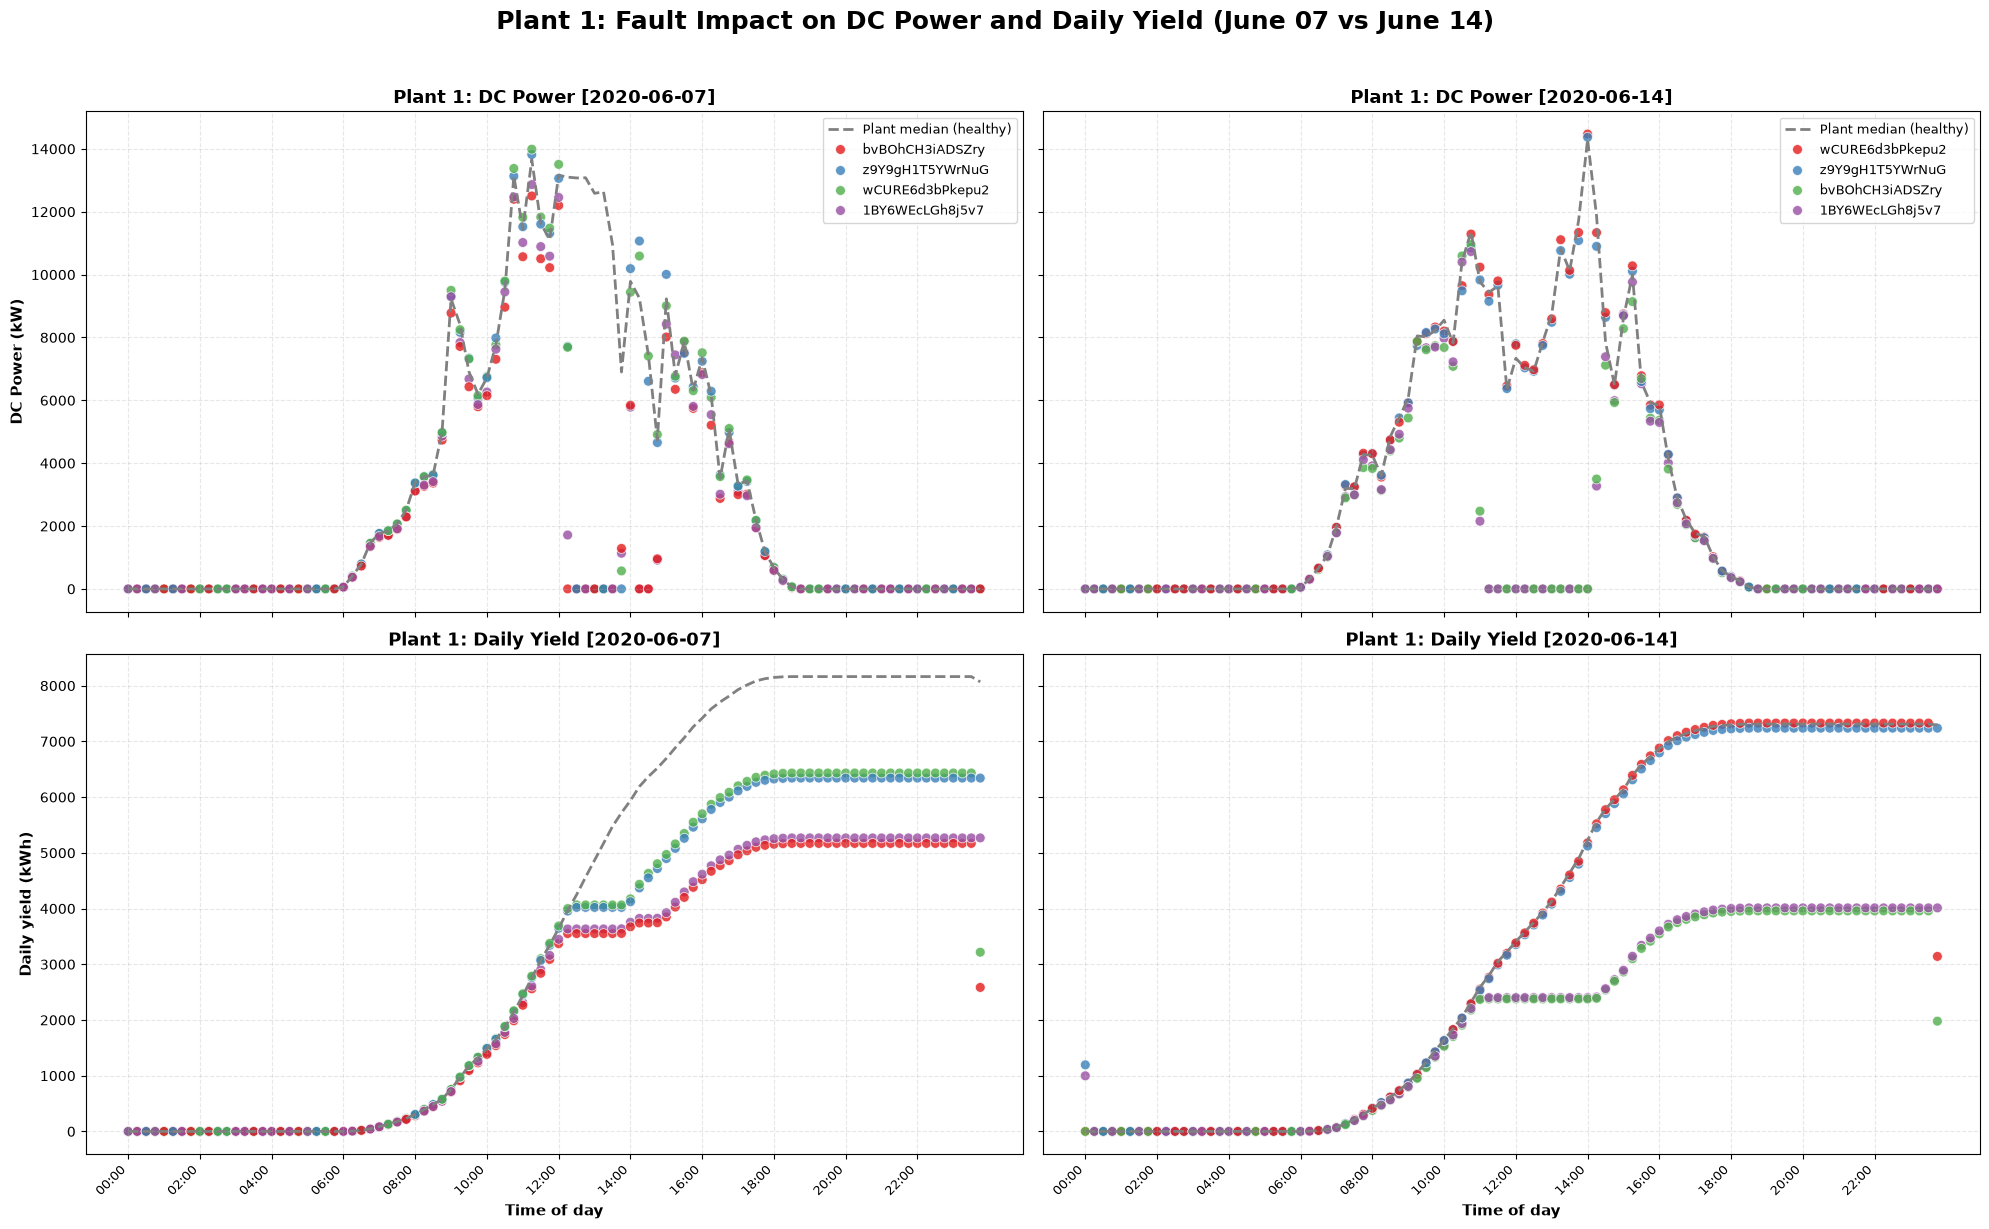

In [12]:
# Section 12: Visualizing two known fault days
logger.info("Plotting DC power and yield impact for two known fault dates.")

p1_gen_clean = plant1_gen_df.copy()
p1_gen_clean['DATE_TIME'] = pd.to_datetime(p1_gen_clean['DATE_TIME'])
p1_gen_clean['DATE_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%Y-%m-%d')
p1_gen_clean['TIME_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%H:%M')

# Use the median across inverters as a healthy-plant reference line
median_dc = p1_gen_clean.groupby('DATE_TIME')['DC_POWER'].median().reset_index().rename(columns={'DC_POWER': 'plant_dc_median'})
median_yield = p1_gen_clean.groupby('DATE_TIME')['DAILY_YIELD'].median().reset_index().rename(columns={'DAILY_YIELD': 'plant_yield_median'})

dash_df = pd.merge(p1_gen_clean, median_dc, on='DATE_TIME', how='left')
dash_df = pd.merge(dash_df, median_yield, on='DATE_TIME', how='left').sort_values('DATE_TIME')

target_dates = ['2020-06-07', '2020-06-14']
culprit_ids = ['1BY6WEcLGh8j5v7', 'bvBOhCH3iADSZry', 'wCURE6d3bPkepu2', 'z9Y9gH1T5YWrNuG']

fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharex='col', sharey='row')

sample_timeline = sorted(dash_df['TIME_STR'].unique())
target_indices = np.arange(0, len(sample_timeline), 8)
target_labels = [sample_timeline[idx] for idx in target_indices]

# Row 1: DC power (root cause)
for idx, current_date in enumerate(target_dates):
    day_df = dash_df[dash_df['DATE_STR'] == current_date]
    culprits_day_df = day_df[day_df['SOURCE_KEY'].isin(culprit_ids)].sort_values('DATE_TIME')
    day_df = day_df.sort_values('DATE_TIME')
    ax = axes[0, idx]

    ax.plot(day_df['TIME_STR'], day_df['plant_dc_median'], color='gray', linestyle='--', lw=2, label='Plant median (healthy)')
    sns.scatterplot(data=culprits_day_df, x='TIME_STR', y='DC_POWER', hue='SOURCE_KEY', palette='Set1', s=50, alpha=0.8, ax=ax)

    ax.set_title(f"Plant 1: DC Power [{current_date}]", fontsize=13, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlabel('')
    if idx == 0:
        ax.set_ylabel("DC Power (kW)", fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)

# Row 2: daily yield (downstream impact)
for idx, current_date in enumerate(target_dates):
    day_df = dash_df[dash_df['DATE_STR'] == current_date]
    culprits_day_df = day_df[day_df['SOURCE_KEY'].isin(culprit_ids)].sort_values('DATE_TIME')
    day_df = day_df.sort_values('DATE_TIME')
    ax = axes[1, idx]

    ax.plot(day_df['TIME_STR'], day_df['plant_yield_median'], color='gray', linestyle='--', lw=2, label='Plant median (healthy)')
    sns.scatterplot(data=culprits_day_df, x='TIME_STR', y='DAILY_YIELD', hue='SOURCE_KEY', palette='Set1', s=50, alpha=0.8, ax=ax, legend=False)

    ax.set_title(f"Plant 1: Daily Yield [{current_date}]", fontsize=13, fontweight='bold')
    ax.set_xlabel("Time of day", fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    if idx == 0:
        ax.set_ylabel("Daily yield (kWh)", fontsize=11, fontweight='bold')
    ax.set_xticks(target_indices)
    ax.set_xticklabels(target_labels, rotation=45, ha='right', fontsize=9)

fig.suptitle(
    "Plant 1: Fault Impact on DC Power and Daily Yield (June 07 vs June 14)",
    fontsize=18, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()


## 13. Weather feature summary statistics

Basic `.describe()` on the weather features to sanity-check ranges (e.g. no negative irradiation).


In [13]:
# Section 13: Weather feature summary statistics
logger.info("Computing summary statistics for weather features.")

weather_features = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
global_weather_summary = plant1_weather_df[weather_features].describe()

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
print(global_weather_summary)
pd.reset_option('display.float_format')


2026-07-05 17:22:30 [INFO] Computing summary statistics for weather features.


       AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION
count           3,182.0000          3,182.0000   3,182.0000
mean               25.5316             31.0910       0.2283
std                 3.3549             12.2612       0.3008
min                20.3985             18.1404       0.0000
25%                22.7052             21.0906       0.0000
50%                24.6138             24.6181       0.0247
75%                27.9205             41.3078       0.4496
max                35.2525             65.5457       1.2217


## 14. Missing-weather-data check

Weather readings should occur every 15 minutes (96 per day). Flag any day with fewer readings as a sensor dropout.


In [14]:
# Section 14: Missing-weather-data check
logger.info("Checking for days with fewer than 96 weather readings.")

weather_check_df = plant1_weather_df[['DATE_TIME']].copy()
weather_check_df['DATE_TIME'] = pd.to_datetime(weather_check_df['DATE_TIME'])
weather_check_df['DATE_STR'] = weather_check_df['DATE_TIME'].dt.strftime('%Y-%m-%d')

weather_daily_check = weather_check_df.groupby('DATE_STR').count().reset_index()
weather_daily_check.columns = ['date', 'row_count']

weather_outage_list = weather_daily_check[weather_daily_check['row_count'] < 96].copy()
weather_outage_list = weather_outage_list.sort_values('date').reset_index(drop=True)

print("\nDays with missing weather readings:")
if not weather_outage_list.empty:
    logger.warning(f"{len(weather_outage_list)} day(s) have fewer than 96 weather readings.")
    print(weather_outage_list.to_string(index=False, formatters={'row_count': '{:,}'.format}))
else:
    print("None — every day has the expected 96 readings.")


2026-07-05 17:22:30 [INFO] Checking for days with fewer than 96 weather readings.


2026-07-05 17:22:30 [WARNING] 8 day(s) have fewer than 96 weather readings.



Days with missing weather readings:
      date row_count
2020-05-15        93
2020-05-16        88
2020-05-19        93
2020-05-20        80
2020-05-21        68
2020-05-23        90
2020-05-29        79
2020-06-03        95


# 15. Data preparation

Prepare a clean, leak-free feature set for modeling: standardize timestamps across both data sources and add convenience date/time string columns for joining and grouping.


In [15]:
# Section 15: Standardize timestamps
logger.info("Preparing Plant 1 data for feature engineering.")

p1_gen_clean = plant1_gen_df.copy()
p1_weather_clean = plant1_weather_df.copy()

p1_gen_clean['DATE_TIME'] = pd.to_datetime(p1_gen_clean['DATE_TIME'])
p1_weather_clean['DATE_TIME'] = pd.to_datetime(p1_weather_clean['DATE_TIME'])

p1_gen_clean['date_str'] = p1_gen_clean['DATE_TIME'].dt.strftime('%Y-%m-%d')
p1_gen_clean['time_str'] = p1_gen_clean['DATE_TIME'].dt.strftime('%H:%M')

p1_weather_clean['date_str'] = p1_weather_clean['DATE_TIME'].dt.strftime('%Y-%m-%d')
p1_weather_clean['time_str'] = p1_weather_clean['DATE_TIME'].dt.strftime('%H:%M')


2026-07-05 17:22:30 [INFO] Preparing Plant 1 data for feature engineering.


## 16. Cleaning and merging into the model feature set

1. Drop the 3-day full blackout window (`2020-05-19` to `2020-05-21`) — no usable signal.
2. Replace peak-hour (11:00–15:00) zero-power readings with the cross-inverter median at that timestamp, to repair the hardware faults found in Section 11.
3. Merge in weather features and linearly interpolate short gaps.
4. Save the result to `data/processed/plant1_master_features.csv`.


In [16]:
# Section 16: Cleaning and merging into the model feature set
logger.info("Cleaning and merging Plant 1 features.")

# Task 1: drop the full blackout window
p1_blackout_dates = ['2020-05-19', '2020-05-20', '2020-05-21']
p1_gen_clean = p1_gen_clean[~p1_gen_clean['date_str'].isin(p1_blackout_dates)].copy()
logger.info(f"Dropped blackout window. Rows remaining: {p1_gen_clean.shape[0]:,}")

# Task 2: replace peak-hour zero-power faults with the cross-inverter median
p1_timestamp_median = p1_gen_clean.groupby('DATE_TIME')['DC_POWER'].median().reset_index()
p1_timestamp_median.columns = ['DATE_TIME', 'healthy_dc_median']
p1_gen_clean = pd.merge(p1_gen_clean, p1_timestamp_median, on='DATE_TIME', how='left')

p1_is_hardware_fault = (
    (p1_gen_clean['time_str'] >= '11:00') &
    (p1_gen_clean['time_str'] <= '15:00') &
    (p1_gen_clean['DC_POWER'] == 0.0)
)
p1_faulty_count = p1_gen_clean[p1_is_hardware_fault].shape[0]
logger.info(f"Replacing {p1_faulty_count:,} peak-hour zero-power readings with the median.")
p1_gen_clean.loc[p1_is_hardware_fault, 'DC_POWER'] = p1_gen_clean.loc[p1_is_hardware_fault, 'healthy_dc_median']

# Task 3: merge weather features and interpolate short gaps
p1_weather_features = p1_weather_clean[['DATE_TIME', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']].copy()
p1_master_df = pd.merge(p1_gen_clean, p1_weather_features, on='DATE_TIME', how='left').sort_values('DATE_TIME').reset_index(drop=True)

weather_cols = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
p1_master_df[weather_cols] = p1_master_df[weather_cols].interpolate(method='linear', limit=2)

# Task 4: save
processed_directory = '../data/processed'
os.makedirs(processed_directory, exist_ok=True)
final_output_path = os.path.join(processed_directory, 'plant1_master_features.csv')
p1_master_df.to_csv(final_output_path, index=False)
logger.info(f"Saved cleaned features to {final_output_path}")

print(f"\nFinal feature set: {p1_master_df.shape[0]:,} rows x {p1_master_df.shape[1]} columns")
print("Remaining nulls in weather columns:")
print(p1_master_df[weather_cols].isnull().sum().to_string())


2026-07-05 17:22:30 [INFO] Cleaning and merging Plant 1 features.


2026-07-05 17:22:30 [INFO] Dropped blackout window. Rows remaining: 63,748


2026-07-05 17:22:30 [INFO] Replacing 58 peak-hour zero-power readings with the median.


2026-07-05 17:22:30 [INFO] Saved cleaned features to ../data/processed/plant1_master_features.csv



Final feature set: 63,748 rows x 14 columns
Remaining nulls in weather columns:
AMBIENT_TEMPERATURE    2
MODULE_TEMPERATURE     2
IRRADIATION            2


## 17. Checking the imputation worked

Compare the raw (faulty) vs cleaned DC power for one known fault case (inverter `1BY6WEcLGh8j5v7` on `2020-06-14`) to confirm the median imputation actually repaired the dropout.


2026-07-05 17:22:30 [INFO] Comparing raw vs cleaned DC power for a known fault case.


2026-07-05 17:22:30 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:30 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:30 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:30 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


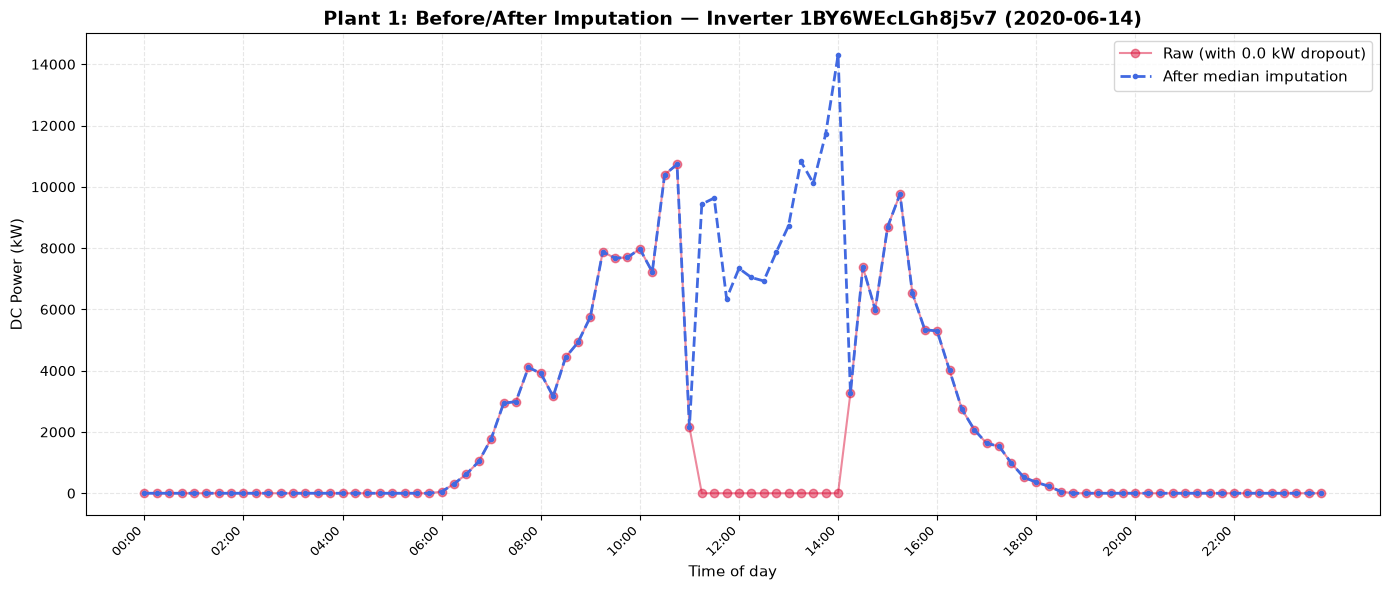

In [17]:
# Section 17: Checking the imputation worked
logger.info("Comparing raw vs cleaned DC power for a known fault case.")

test_date = '2020-06-14'
test_culprit = '1BY6WEcLGh8j5v7'

raw_staging = plant1_gen_df.copy()
raw_staging['DATE_TIME'] = pd.to_datetime(raw_staging['DATE_TIME'])
raw_staging['date_str'] = raw_staging['DATE_TIME'].dt.strftime('%Y-%m-%d')
raw_staging['time_str'] = raw_staging['DATE_TIME'].dt.strftime('%H:%M')

raw_day = raw_staging[(raw_staging['date_str'] == test_date) & (raw_staging['SOURCE_KEY'] == test_culprit)].sort_values('DATE_TIME')
clean_day = p1_master_df[(p1_master_df['date_str'] == test_date) & (p1_master_df['SOURCE_KEY'] == test_culprit)].sort_values('DATE_TIME')

plt.figure(figsize=(14, 6))
plt.plot(raw_day['time_str'], raw_day['DC_POWER'], color='crimson', marker='o', alpha=0.5, label='Raw (with 0.0 kW dropout)')
plt.plot(clean_day['time_str'], clean_day['DC_POWER'], color='royalblue', marker='.', linestyle='--', lw=2, label='After median imputation')

ax = plt.gca()
sample_timeline = sorted(raw_day['time_str'].unique())
target_indices = np.arange(0, len(sample_timeline), 8)
target_labels = [sample_timeline[idx] for idx in target_indices]
ax.set_xticks(target_indices)
ax.set_xticklabels(target_labels, rotation=45, ha='right', fontsize=9)

plt.title(f"Plant 1: Before/After Imputation — Inverter {test_culprit} ({test_date})", fontsize=14, fontweight='bold')
plt.xlabel("Time of day", fontsize=11)
plt.ylabel("DC Power (kW)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()


# 18. Train/test split and model training

Train a LightGBM regressor on `AMBIENT_TEMPERATURE`, `MODULE_TEMPERATURE`, and `IRRADIATION` to predict `DC_POWER`. Split chronologically instead of randomly, so the test set is a genuinely unseen future period:
- Train: 2020-05-15 to 2020-06-11
- Test: 2020-06-12 to 2020-06-17

A random split would leak information from the test period's neighboring timestamps into training, since consecutive readings are highly correlated — a chronological split avoids that.


In [18]:
# Section 18: Train/test split and model training
logger.info("Splitting data chronologically and training the LightGBM model.")

p1_master_df['DATE_TIME'] = pd.to_datetime(p1_master_df['DATE_TIME'])
if 'date_str' not in p1_master_df.columns:
    p1_master_df['date_str'] = p1_master_df['DATE_TIME'].dt.strftime('%Y-%m-%d')
if 'time_str' not in p1_master_df.columns:
    p1_master_df['time_str'] = p1_master_df['DATE_TIME'].dt.strftime('%H:%M')

X_master = p1_master_df[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']]
y_master = p1_master_df['DC_POWER']
dates = p1_master_df['date_str']

train_mask = dates <= '2020-06-11'
test_mask = (dates >= '2020-06-12') & (dates <= '2020-06-17')

X_train, y_train = X_master[train_mask], y_master[train_mask]
X_test, y_test = X_master[test_mask], y_master[test_mask]

print(f"Train rows (05/15-06/11): {X_train.shape[0]:,}")
print(f"Test rows  (06/12-06/17): {X_test.shape[0]:,}")

verify_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
verify_model.fit(X_train, y_train)

y_pred = verify_model.predict(X_test)

rmse_eval = np.sqrt(mean_squared_error(y_test, y_pred))
r2_eval = r2_score(y_test, y_pred)

print(f"\nTest RMSE: {rmse_eval:.4f} kW")
print(f"Test R2:   {r2_eval:.4f} ({r2_eval*100:.2f}%)")


2026-07-05 17:22:31 [INFO] Splitting data chronologically and training the LightGBM model.


Train rows (05/15-06/11): 51,120
Test rows  (06/12-06/17): 12,628



Test RMSE: 388.5018 kW
Test R2:   0.9894 (98.94%)


## 19. Visualizing predictions vs actual

Plot the model's predictions against actual DC power over the full test window, then zoom into one day (`2020-06-17`) to check the diurnal shape is tracked accurately.


2026-07-05 17:22:31 [INFO] Plotting predicted vs actual DC power over the test window.


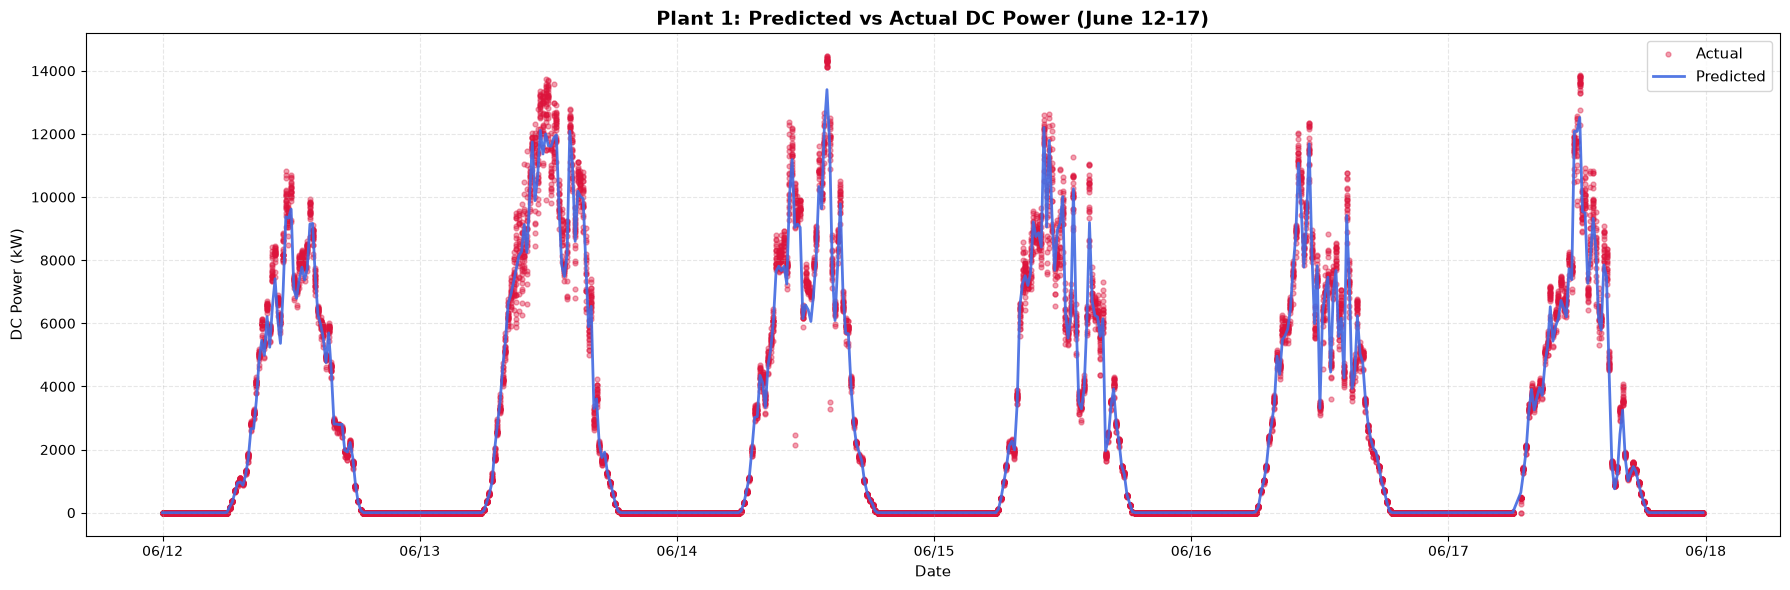

2026-07-05 17:22:31 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:31 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:31 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-05 17:22:31 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


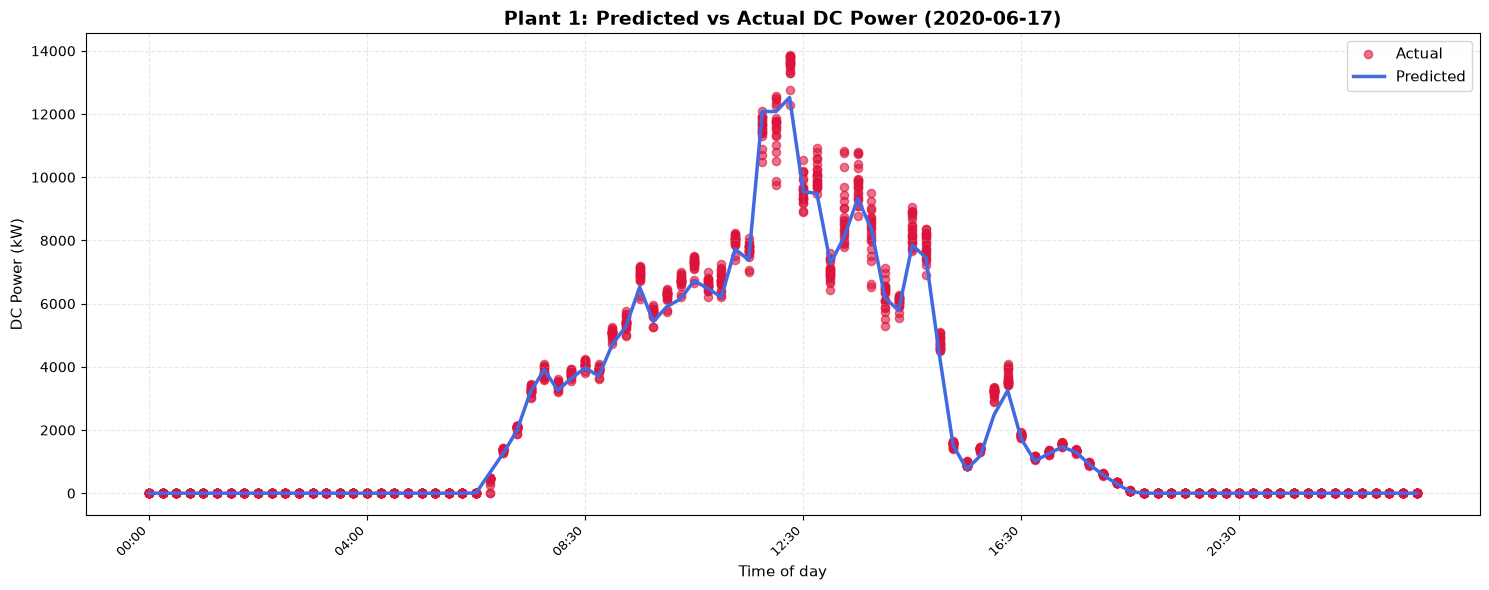

In [19]:
# Section 19: Visualizing predictions vs actual
logger.info("Plotting predicted vs actual DC power over the test window.")

# Rebuild the split/model if running this cell after a kernel restart
if 'y_pred' not in locals() or 'test_mask' not in locals():
    p1_master_df['DATE_TIME'] = pd.to_datetime(p1_master_df['DATE_TIME'])
    if 'date_str' not in p1_master_df.columns:
        p1_master_df['date_str'] = p1_master_df['DATE_TIME'].dt.strftime('%Y-%m-%d')
    if 'time_str' not in p1_master_df.columns:
        p1_master_df['time_str'] = p1_master_df['DATE_TIME'].dt.strftime('%H:%M')

    X_master = p1_master_df[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']]
    y_master = p1_master_df['DC_POWER']
    dates = p1_master_df['date_str']

    train_mask = dates <= '2020-06-11'
    test_mask = (dates >= '2020-06-12') & (dates <= '2020-06-17')

    X_train, y_train = X_master[train_mask], y_master[train_mask]
    X_test, y_test = X_master[test_mask], y_master[test_mask]

    fallback_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
    fallback_model.fit(X_train, y_train)
    y_pred = fallback_model.predict(X_test)

eval_df = p1_master_df[test_mask].copy().sort_values('DATE_TIME')
eval_df['pred_dc_power'] = y_pred

# Chart 1: full test window
plt.figure(figsize=(18, 6))
plt.scatter(eval_df['DATE_TIME'], eval_df['DC_POWER'], color='crimson', alpha=0.4, s=12, label='Actual')
plt.plot(eval_df['DATE_TIME'], eval_df['pred_dc_power'], color='royalblue', lw=2, alpha=0.9, label='Predicted')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator())

plt.title("Plant 1: Predicted vs Actual DC Power (June 12-17)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("DC Power (kW)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

# Chart 2: zoom into one day
target_focus_date = '2020-06-17'
final_day_df = eval_df[eval_df['date_str'] == target_focus_date].sort_values('DATE_TIME')

plt.figure(figsize=(15, 6))
plt.scatter(final_day_df['time_str'], final_day_df['DC_POWER'], color='crimson', alpha=0.6, s=35, label='Actual')
plt.plot(final_day_df['time_str'], final_day_df['pred_dc_power'], color='royalblue', lw=2.5, label='Predicted')

ax = plt.gca()
sample_timeline = sorted(final_day_df['time_str'].unique())
target_indices = np.arange(0, len(sample_timeline), 16)
target_labels = [sample_timeline[idx] for idx in target_indices]
ax.set_xticks(target_indices)
ax.set_xticklabels(target_labels, rotation=45, ha='right', fontsize=9)

plt.title(f"Plant 1: Predicted vs Actual DC Power ({target_focus_date})", fontsize=14, fontweight='bold')
plt.xlabel("Time of day", fontsize=11)
plt.ylabel("DC Power (kW)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()


## 20. Feature importance and correlations

Check which features the model relies on most (LightGBM feature importance) and compare against simple linear Pearson correlations, to confirm the model's behavior matches physical intuition (irradiation should dominate).


2026-07-05 17:22:31 [INFO] Plotting feature importance and correlation matrix.


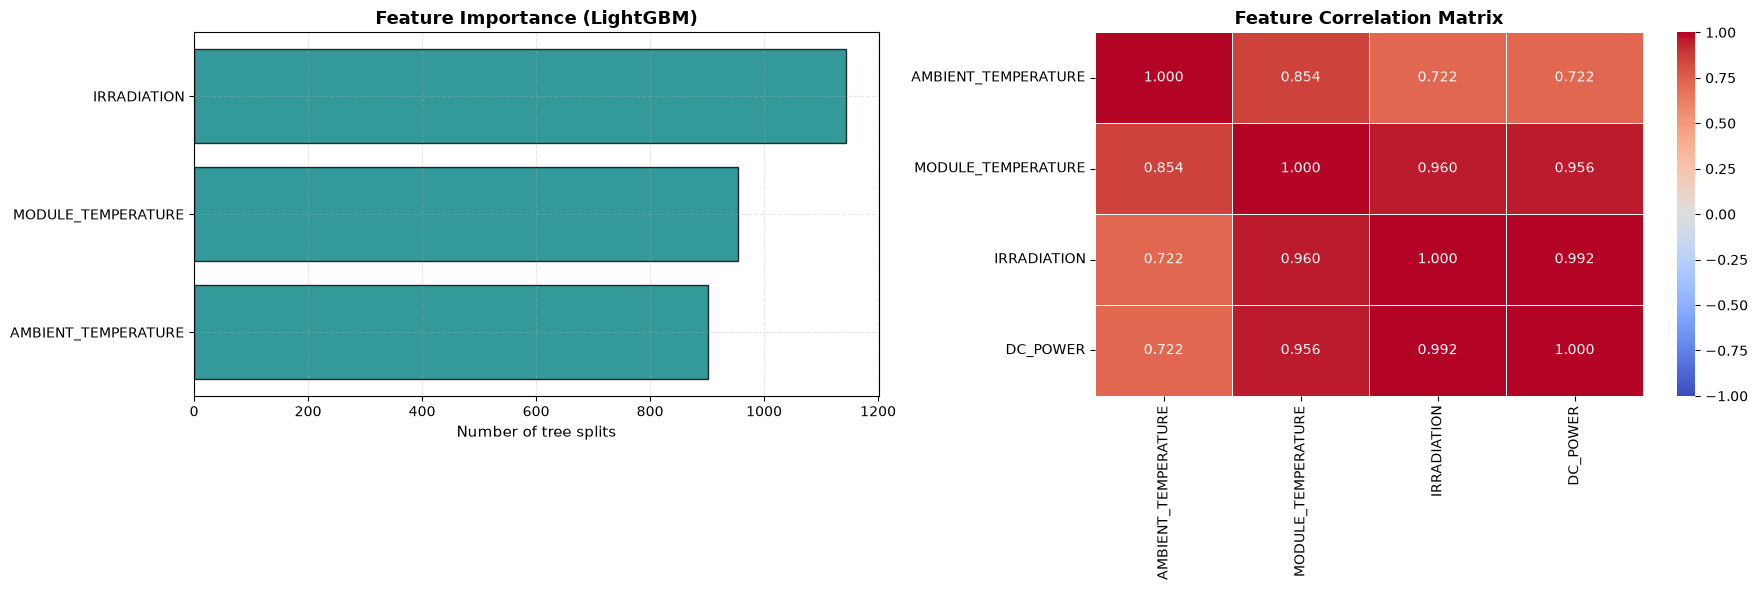

In [20]:
# Section 20: Feature importance and correlations
logger.info("Plotting feature importance and correlation matrix.")

# Rebuild the model if running this cell after a kernel restart
if 'verify_model' not in locals() or 'X_train' not in locals():
    p1_master_df['DATE_TIME'] = pd.to_datetime(p1_master_df['DATE_TIME'])
    if 'date_str' not in p1_master_df.columns:
        p1_master_df['date_str'] = p1_master_df['DATE_TIME'].dt.strftime('%Y-%m-%d')

    X_master = p1_master_df[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']]
    y_master = p1_master_df['DC_POWER']
    dates = p1_master_df['date_str']

    train_mask = dates <= '2020-06-11'
    X_train, y_train = X_master[train_mask], y_master[train_mask]

    verify_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
    verify_model.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1: LightGBM feature importance
importance = verify_model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importance}).sort_values('importance', ascending=True)

axes[0].barh(importance_df['feature'], importance_df['importance'], color='teal', edgecolor='black', alpha=0.8)
axes[0].set_title("Feature Importance (LightGBM)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Number of tree splits", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.3)

# Chart 2: Pearson correlation
analysis_cols = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'DC_POWER']
correlation_matrix = p1_master_df[analysis_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Feature Correlation Matrix", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


## 21. Converting predictions to daily energy (kWh)

Apply a 92% inverter efficiency factor to convert predicted/actual DC power to AC, then integrate over 15-minute intervals to get daily energy totals (kWh) — the unit that actually matters for grid planning — and compare predicted vs actual per day.


2026-07-05 17:22:31 [INFO] Converting DC power predictions to daily AC energy (kWh).


      date actual_daily_yield_kwh predicted_daily_yield_kwh error_delta_kwh
2020-06-12           1,201,141.40              1,144,901.72      -56,239.68
2020-06-13           1,746,568.54              1,715,426.32      -31,142.22
2020-06-14           1,511,346.21              1,451,036.03      -60,310.18
2020-06-15           1,392,773.26              1,387,341.56       -5,431.70
2020-06-16           1,284,979.15              1,261,088.32      -23,890.83
2020-06-17           1,223,089.36              1,176,107.98      -46,981.38


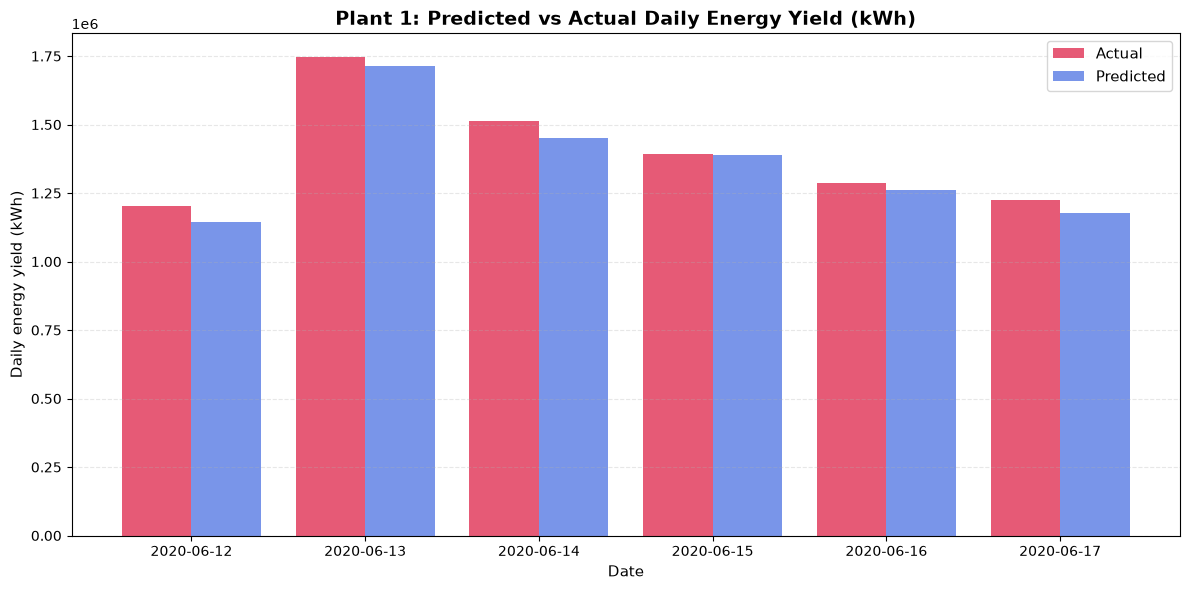

In [21]:
# Section 21: Converting predictions to daily energy (kWh)
logger.info("Converting DC power predictions to daily AC energy (kWh).")

# Rebuild the split/model if running this cell after a kernel restart
if 'y_pred' not in locals() or 'test_mask' not in locals():
    p1_master_df['DATE_TIME'] = pd.to_datetime(p1_master_df['DATE_TIME'])
    if 'date_str' not in p1_master_df.columns:
        p1_master_df['date_str'] = p1_master_df['DATE_TIME'].dt.strftime('%Y-%m-%d')

    X_master = p1_master_df[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']]
    y_master = p1_master_df['DC_POWER']
    dates = p1_master_df['date_str']

    train_mask = dates <= '2020-06-11'
    test_mask = (dates >= '2020-06-12') & (dates <= '2020-06-17')

    X_train, y_train = X_master[train_mask], y_master[train_mask]
    X_test, y_test = X_master[test_mask], y_master[test_mask]

    fallback_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
    fallback_model.fit(X_train, y_train)
    y_pred = fallback_model.predict(X_test)

eval_df = p1_master_df[test_mask].copy().sort_values('DATE_TIME')
eval_df['pred_dc_power'] = y_pred

INVERTER_EFFICIENCY = 0.92
eval_df['actual_ac_power_sim'] = eval_df['DC_POWER'] * INVERTER_EFFICIENCY
eval_df['pred_ac_power_sim'] = eval_df['pred_dc_power'] * INVERTER_EFFICIENCY

# 15-minute intervals = 0.25 hours; kW x hours = kWh
eval_df['actual_kwh'] = eval_df['actual_ac_power_sim'] * 0.25
eval_df['pred_kwh'] = eval_df['pred_ac_power_sim'] * 0.25

daily_yield_report = eval_df.groupby('date_str')[['actual_kwh', 'pred_kwh']].sum().reset_index()
daily_yield_report.columns = ['date', 'actual_daily_yield_kwh', 'predicted_daily_yield_kwh']
daily_yield_report['error_delta_kwh'] = daily_yield_report['predicted_daily_yield_kwh'] - daily_yield_report['actual_daily_yield_kwh']

print(daily_yield_report.to_string(index=False, formatters={
    'actual_daily_yield_kwh': '{:,.2f}'.format,
    'predicted_daily_yield_kwh': '{:,.2f}'.format,
    'error_delta_kwh': '{:+,.2f}'.format
}))

plt.figure(figsize=(12, 6))
x_axis = np.arange(len(daily_yield_report['date']))
plt.bar(x_axis - 0.2, daily_yield_report['actual_daily_yield_kwh'], width=0.4, color='crimson', alpha=0.7, label='Actual')
plt.bar(x_axis + 0.2, daily_yield_report['predicted_daily_yield_kwh'], width=0.4, color='royalblue', alpha=0.7, label='Predicted')

plt.xticks(x_axis, daily_yield_report['date'])
plt.title("Plant 1: Predicted vs Actual Daily Energy Yield (kWh)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Daily energy yield (kWh)", fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()
